# 10K Variational Autoencoder (v2: Beta-VAE)

This notebook introduces the Beta parameter to downscale the KL divergence penalty, curing the 'VAE Blur' effect and returning sharp reconstructions while preserving generative latent space. It outputs a comprehensive `VAE_v2_10K_Results.zip` archive.


In [1]:
import os
import random
import hashlib
import json
import shutil
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import FileLink

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 1. Load Dataset & Exact Split


In [2]:
!pip install -q datasets
from datasets import load_dataset
dataset = load_dataset("evilsocket/alucard-sprites")
train_data = dataset["train"]

def image_hash(image):
    pixels = np.asarray(image.convert("RGBA"), dtype=np.uint8)
    return hashlib.sha256(pixels.tobytes()).hexdigest()

all_hashes = []
seen_hashes = set()
for i, item in enumerate(train_data):
    h = image_hash(item["image"])
    if h not in seen_hashes:
        seen_hashes.add(h)
        all_hashes.append(i)

unique_dataset = train_data.select(all_hashes)

SEED = 42
unique_dataset = unique_dataset.shuffle(seed=SEED)

TRAIN_SIZE = 9_000
VAL_SIZE = 1_000
TEST_SIZE = 1_000
TOTAL_SIZE = TRAIN_SIZE + VAL_SIZE + TEST_SIZE

clean_dataset = unique_dataset.select(range(TOTAL_SIZE))
train_dataset = clean_dataset.select(range(0, TRAIN_SIZE))
val_dataset = clean_dataset.select(range(TRAIN_SIZE, TRAIN_SIZE + VAL_SIZE))
test_dataset = clean_dataset.select(range(TRAIN_SIZE + VAL_SIZE, TOTAL_SIZE))

print("Training:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00006.parquet:   0%|          | 0.00/195M [00:00<?, ?B/s]

data/train-00001-of-00006.parquet:   0%|          | 0.00/195M [00:00<?, ?B/s]

data/train-00002-of-00006.parquet:   0%|          | 0.00/196M [00:00<?, ?B/s]

data/train-00003-of-00006.parquet:   0%|          | 0.00/197M [00:00<?, ?B/s]

data/train-00004-of-00006.parquet:   0%|          | 0.00/195M [00:00<?, ?B/s]

data/train-00005-of-00006.parquet:   0%|          | 0.00/194M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/312550 [00:00<?, ? examples/s]

Training: 9000
Validation: 1000
Test: 1000


In [3]:
def data_generator(hf_dataset):
    for item in hf_dataset:
        image = item["image"]
        image = image.convert("RGBA")
        image_np = np.array(image, dtype=np.float32) / 255.0
        yield (image_np, image_np)

BATCH_SIZE = 32

def create_tf_dataset(hf_dataset):
    return tf.data.Dataset.from_generator(
        lambda: data_generator(hf_dataset),
        output_signature=(
            tf.TensorSpec(shape=(128, 128, 4), dtype=tf.float32),
            tf.TensorSpec(shape=(128, 128, 4), dtype=tf.float32)
        )
    )

train_tf = create_tf_dataset(train_dataset).batch(BATCH_SIZE).repeat().prefetch(tf.data.AUTOTUNE)
val_tf = create_tf_dataset(val_dataset).batch(BATCH_SIZE).repeat().prefetch(tf.data.AUTOTUNE)
test_tf = create_tf_dataset(test_dataset).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_originals = []
for images, _ in test_tf.take(2): # load 64 images for quick eval plotting
    test_originals.append(images.numpy())
test_originals = np.concatenate(test_originals, axis=0)
print("Pipelines ready.")


I0000 00:00:1787398145.933620      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787398145.936391      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Pipelines ready.


## 2. Beta-VAE Architecture


In [4]:
latent_dim = 256

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# Encoder
encoder_inputs = keras.Input(shape=(128, 128, 4))
x = layers.Conv2D(32, 3, activation="relu", padding="same", strides=2)(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", padding="same", strides=2)(x)
x = layers.Conv2D(128, 3, activation="relu", padding="same", strides=2)(x)
x = layers.Conv2D(256, 3, activation="relu", padding="same", strides=2)(x)
x = layers.Flatten()(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# Decoder
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(8 * 8 * 256, activation="relu")(latent_inputs)
x = layers.Reshape((8, 8, 256))(x)
x = layers.Conv2DTranspose(128, 4, activation="relu", padding="same", strides=2)(x)
x = layers.Conv2DTranspose(64, 4, activation="relu", padding="same", strides=2)(x)
x = layers.Conv2DTranspose(32, 4, activation="relu", padding="same", strides=2)(x)
decoder_outputs = layers.Conv2DTranspose(4, 4, activation="sigmoid", padding="same", strides=2)(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")

class BetaVAE(keras.Model):
    def __init__(self, encoder, decoder, beta=0.001, **kwargs):
        super(BetaVAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta
        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def call(self, inputs):
        _, _, z = self.encoder(inputs)
        return self.decoder(z)

    def train_step(self, data):
        x, _ = data
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(x)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(tf.square(x - reconstruction), axis=(1, 2, 3))
            )
            # The Beta multiplier is applied here!
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = self.beta * tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
            
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        x, _ = data
        z_mean, z_log_var, z = self.encoder(x)
        reconstruction = self.decoder(z)
        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(tf.square(x - reconstruction), axis=(1, 2, 3))
        )
        kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_loss = self.beta * tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
        total_loss = reconstruction_loss + kl_loss
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

vae = BetaVAE(encoder, decoder, beta=0.001)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))
vae.build((None, 128, 128, 4))
vae.summary()


Model: "beta_vae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Functional)            │ ((None, 256), (None,   │     8,777,824 │
│                                 │ 256), (None, 256))     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 128, 128, 4)    │     4,901,092 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,678,916 (52.18 MB)

 Trainable params: 13,678,916 (52.18 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Training & Checkpointing


In [5]:
MODEL_DIR = "/kaggle/working/VAE_v2_10K_Results"
os.makedirs(MODEL_DIR, exist_ok=True)

class SaveHistoryCallback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        hist_path = os.path.join(MODEL_DIR, "training_history.json")
        history = json.load(open(hist_path, "r")) if os.path.exists(hist_path) else {}
        for k, v in logs.items():
            history.setdefault(k, []).append(float(v))
        with open(hist_path, "w") as f:
            json.dump(history, f)

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint(filepath=os.path.join(MODEL_DIR, "latest.weights.h5"), save_weights_only=True),
    keras.callbacks.ModelCheckpoint(filepath=os.path.join(MODEL_DIR, "best.weights.h5"), save_best_only=True, monitor="val_loss", save_weights_only=True),
    SaveHistoryCallback()
]

history = vae.fit(
    train_tf,
    steps_per_epoch=282, # 9000/32
    epochs=50,
    validation_data=val_tf,
    validation_steps=32,
    callbacks=callbacks
)


Epoch 1/50


2026-08-22 11:29:13.119340: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-22 11:29:13.259149: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  5/282 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - kl_loss: 0.0035 - loss: 13219.4375 - reconstruction_loss: 13219.4340   

I0000 00:00:1787398156.872791     165 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


282/282 ━━━━━━━━━━━━━━━━━━━━ 29s 70ms/step - kl_loss: 1.2261 - loss: 3562.2278 - reconstruction_loss: 3561.0012 - val_kl_loss: 1.1836 - val_loss: 1901.5543 - val_reconstruction_loss: 1900.3710
Epoch 2/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 13s 46ms/step - kl_loss: 1.2284 - loss: 1664.1329 - reconstruction_loss: 1662.9052 - val_kl_loss: 1.2124 - val_loss: 1538.0383 - val_reconstruction_loss: 1536.8257
Epoch 3/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 13s 46ms/step - kl_loss: 1.3445 - loss: 1386.3981 - reconstruction_loss: 1385.0540 - val_kl_loss: 1.4425 - val_loss: 1295.7649 - val_reconstruction_loss: 1294.3223
Epoch 4/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 13s 46ms/step - kl_loss: 1.4213 - loss: 1179.2104 - reconstruction_loss: 1177.7887 - val_kl_loss: 1.4650 - val_loss: 1154.0549 - val_reconstruction_loss: 1152.5901
Epoch 5/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 13s 46ms/step - kl_loss: 1.5804 - loss: 1037.8951 - reconstruction_loss: 1036.3149 - val_kl_loss: 1.6343 - val_loss: 1015.6893 - val_reconstruction_loss: 1

## 4. Comprehensive Evaluation & Download Hook


In [6]:
print("Saving comprehensive model artifacts...")

# 1. Save individual weights
vae.save_weights(os.path.join(MODEL_DIR, "vae_10k_final.weights.h5"))
encoder.save_weights(os.path.join(MODEL_DIR, "encoder_10k_final.weights.h5"))
decoder.save_weights(os.path.join(MODEL_DIR, "decoder_10k_final.weights.h5"))

# 2. Save Model Summary
with open(os.path.join(MODEL_DIR, "vae_model_summary.txt"), "w") as f:
    vae.summary(print_fn=lambda x: f.write(x + "\n"))
    encoder.summary(print_fn=lambda x: f.write(x + "\n"))
    decoder.summary(print_fn=lambda x: f.write(x + "\n"))

# 3. Save Architecture Info & Config
arch_info = {
    "input_shape": [128, 128, 4],
    "latent_shape": [8, 8, 256],
    "encoder_layers": [layer.name for layer in encoder.layers],
    "decoder_layers": [layer.name for layer in decoder.layers]
}
with open(os.path.join(MODEL_DIR, "architecture_info.json"), "w") as f:
    json.dump(arch_info, f, indent=4)

config_info = {
    "epochs": 50,
    "batch_size": BATCH_SIZE,
    "learning_rate": 1e-3,
    "optimizer": "Adam",
    "loss": "Beta-VAE SSE",
    "beta": 0.001
}
with open(os.path.join(MODEL_DIR, "experiment_config.json"), "w") as f:
    json.dump(config_info, f, indent=4)

# 4. Save Evaluation Metrics
test_reconstructions = vae.predict(test_originals)
test_mse = float(np.mean(np.square(test_originals - test_reconstructions)))
test_psnr = float(np.mean(tf.image.psnr(test_originals, test_reconstructions, max_val=1.0).numpy()))
metrics = {
    "test_mse": test_mse,
    "test_psnr": test_psnr
}
with open(os.path.join(MODEL_DIR, "evaluation_metrics.json"), "w") as f:
    json.dump(metrics, f, indent=4)

# 5. Save Reconstructions Grid Images
recon_dir = os.path.join(MODEL_DIR, "reconstructions")
os.makedirs(recon_dir, exist_ok=True)
random_indices = np.random.choice(len(test_originals), 5, replace=False)
for i, idx in enumerate(random_indices):
    orig_img = (test_originals[idx] * 255).astype(np.uint8)
    recon_img = (test_reconstructions[idx] * 255).astype(np.uint8)
    Image.fromarray(orig_img).save(os.path.join(recon_dir, f"sample_{i}_original.png"))
    Image.fromarray(recon_img).save(os.path.join(recon_dir, f"sample_{i}_reconstruction.png"))

print("All comprehensive files saved to", MODEL_DIR)

# 6. Zip and download
zip_path = "/kaggle/working/VAE_v2_10K_Results"
shutil.make_archive(zip_path, 'zip', MODEL_DIR)

print(f"Created {zip_path}.zip with ALL comprehensive files!")
FileLink(r'VAE_v2_10K_Results.zip')


Saving comprehensive model artifacts...


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
All comprehensive files saved to /kaggle/working/VAE_v2_10K_Results
Created /kaggle/working/VAE_v2_10K_Results.zip with ALL comprehensive files!


/kaggle/working/VAE_v2_10K_Results.zip

Generating VAE Visualizations...


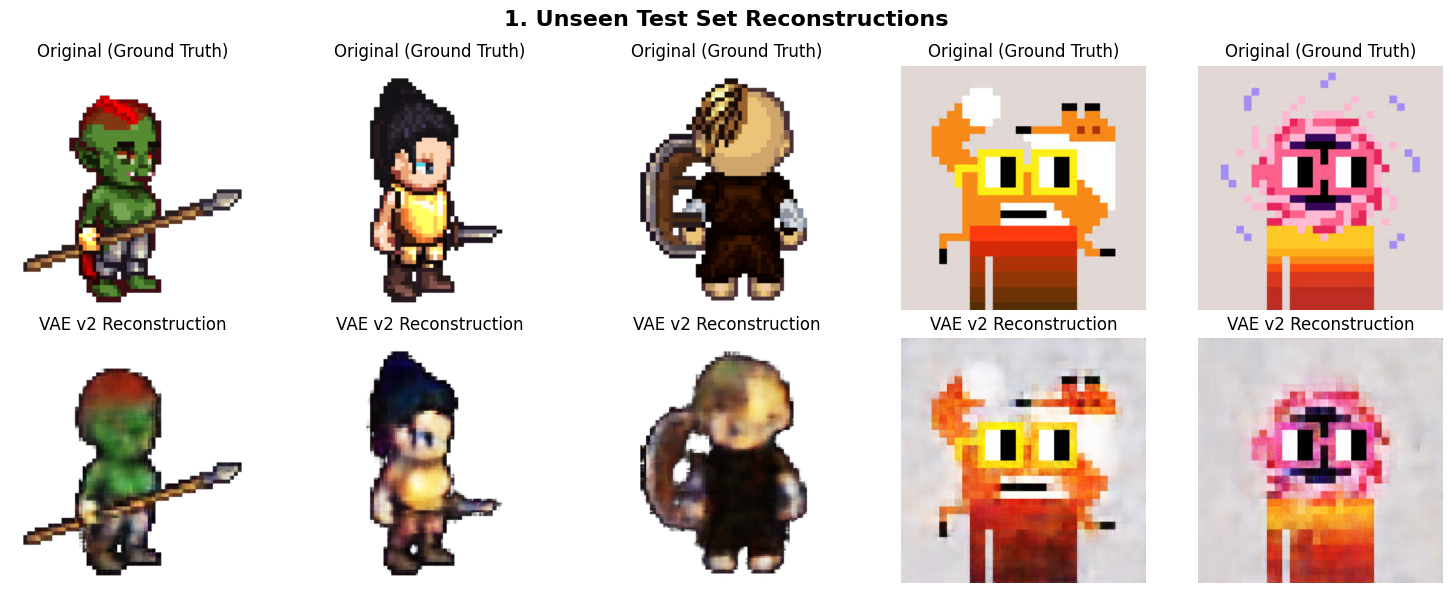

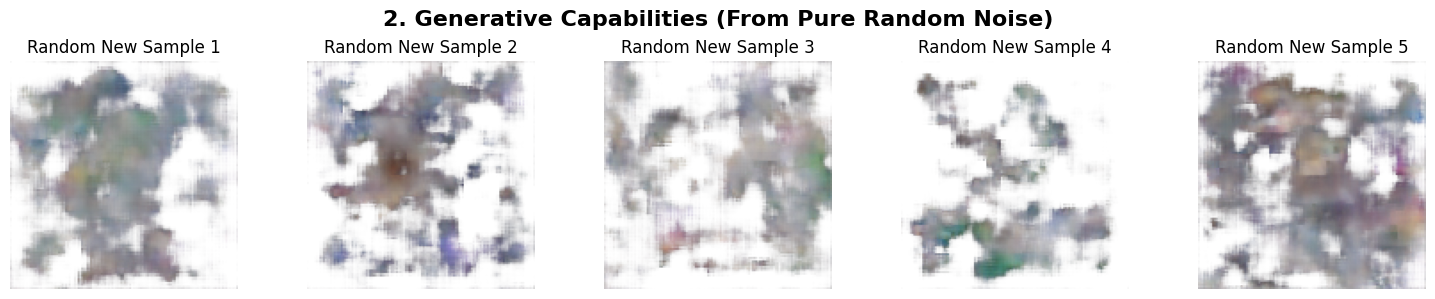

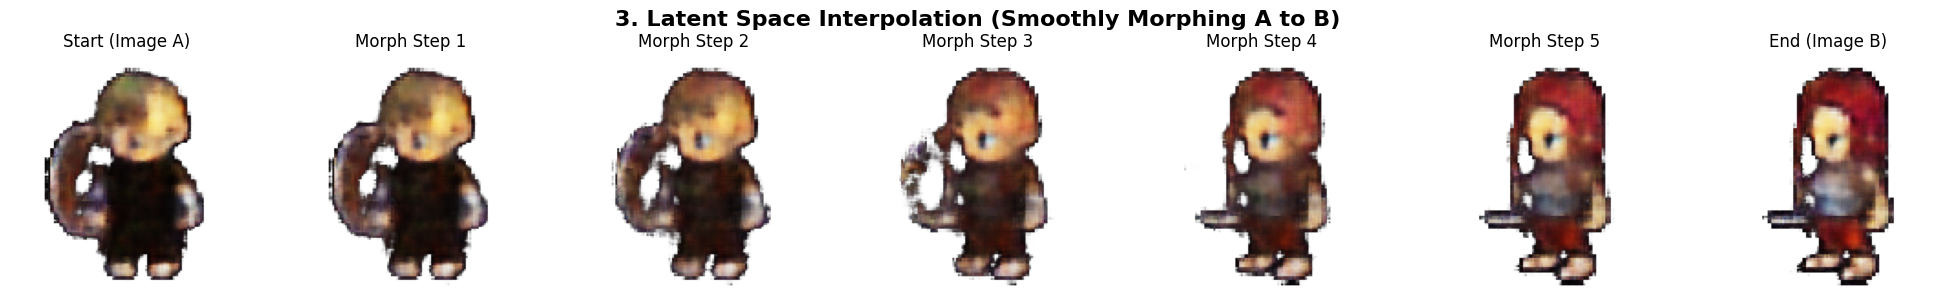

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import random

print("Generating VAE Visualizations...")

# ==========================================
# 1. TEST SET RECONSTRUCTIONS
# ==========================================
num_recon = 5
random_indices = random.sample(range(len(test_originals)), num_recon)
recon_inputs = test_originals[random_indices]
recon_outputs = vae.predict(recon_inputs, verbose=0)

fig, axes = plt.subplots(2, num_recon, figsize=(15, 6))
for i in range(num_recon):
    # Original
    axes[0, i].imshow(recon_inputs[i])
    axes[0, i].set_title("Original (Ground Truth)")
    axes[0, i].axis("off")
    # Reconstruction
    axes[1, i].imshow(recon_outputs[i])
    axes[1, i].set_title("VAE v2 Reconstruction")
    axes[1, i].axis("off")
plt.suptitle("1. Unseen Test Set Reconstructions", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

# ==========================================
# 2. RANDOM LATENT GENERATION
# ==========================================
num_gen = 5
# Sample pure random noise from a standard normal distribution
random_latents = np.random.normal(0, 1, size=(num_gen, latent_dim))
generated_images = decoder.predict(random_latents, verbose=0)

fig, axes = plt.subplots(1, num_gen, figsize=(15, 3))
for i in range(num_gen):
    axes[i].imshow(generated_images[i])
    axes[i].set_title(f"Random New Sample {i+1}")
    axes[i].axis("off")
plt.suptitle("2. Generative Capabilities (From Pure Random Noise)", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

# ==========================================
# 3. LATENT SPACE INTERPOLATION (MORPHING)
# ==========================================
num_steps = 7
# Pick two random images to morph between
idx1, idx2 = random.sample(range(len(test_originals)), 2)
img1, img2 = test_originals[idx1:idx1+1], test_originals[idx2:idx2+1]

# Get their exact latent coordinates (using z_mean)
z_mean1, _, _ = encoder.predict(img1, verbose=0)
z_mean2, _, _ = encoder.predict(img2, verbose=0)

# Create mathematical stepping stones (linear interpolation) between point A and point B
alphas = np.linspace(0, 1, num_steps)
interpolated_latents = np.array([(1 - a) * z_mean1[0] + a * z_mean2[0] for a in alphas])

# Decode the interpolated points back into images
morphed_images = decoder.predict(interpolated_latents, verbose=0)

fig, axes = plt.subplots(1, num_steps, figsize=(20, 3))
for i in range(num_steps):
    axes[i].imshow(morphed_images[i])
    title = "Start (Image A)" if i == 0 else "End (Image B)" if i == num_steps-1 else f"Morph Step {i}"
    axes[i].set_title(title)
    axes[i].axis("off")
plt.suptitle("3. Latent Space Interpolation (Smoothly Morphing A to B)", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()
